# Full-triplet Markov music sampler with gate knobs

This notebook reworks the token Markov sampler into a packed full-triplet register:

```text
[interval bits][duration bits][silence bits]
```

The generator still learns first-order transition probabilities `P(next_triplet | current_triplet)`, but each measured state decodes directly into `(interval, duration, silence)`. A configurable knob block is appended after state preparation and before measurement. The knob block can target interval, duration, and silence bit groups separately with `RY`, `CRY`, or `CRX` rotations.

Use the UI near the bottom to set gate types and angles, then press **Generate** or **Preview global distribution**.


In [25]:
# If this notebook is running in a fresh environment, uncomment these lines first.
# %pip install qiskit qiskit-aer matplotlib numpy pylatexenc ipywidgets

from __future__ import annotations

from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path
import os
import wave

os.environ.setdefault("MPLCONFIGDIR", str(Path(".matplotlib-cache").resolve()))
Path(os.environ["MPLCONFIGDIR"]).mkdir(exist_ok=True)

import numpy as np
import matplotlib.pyplot as plt

SEED = 2026
rng = np.random.default_rng(SEED)
np.set_printoptions(precision=4, suppress=True)

MIDI_DIR = Path("midi")
OUTPUT_DIR = Path("outputs_triplet_knobs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Data selection. If USER_MIDI_PATHS is empty, a reproducible random subset is used.
NUM_SOURCE_SONGS =10
USER_MIDI_PATHS = [
    # "midi/0002_M_E1M1.lmp",
    # "midi/0004_M_E1M3.lmp",
]
TRACK_SELECTION_BY_FILE = {
    # "0002_M_E1M1.lmp": 2,
}

# Packed full-triplet register. Increase these if your machine can tolerate larger StatePreparation vectors.
INTERVAL_BITS = 6
DURATION_BITS = 5
SILENCE_BITS = 5
MAX_CONFIGURABLE_QUBITS = 32
MAX_COMFORTABLE_STATEPREP_QUBITS = 16
ALLOW_LARGE_STATEPREP = False

# Conditional circuits are built only for common current states; rare states use the global circuit.
MAX_CONDITIONAL_CIRCUITS = 32
MIN_TRANSITION_COUNT = 6
TRANSITION_SMOOTHING_ALPHA = 0.10
GLOBAL_MIX_PROBABILITY = 0.08

# Durations and silences use grid steps so files with different ticks-per-beat can mix.
DURATION_GRID_STEPS_PER_BEAT = 4

GENERATED_EVENTS = 192
SMOKE_TEST_EVENTS = 16
DISTRIBUTION_PREVIEW_SHOTS = 2048
SMOKE_PREVIEW_SHOTS = 256
OUTPUT_LOW_PITCH = 45
OUTPUT_HIGH_PITCH = 84

DRAW_CIRCUIT_IMAGES = True
RUN_HEADLESS_SMOKE_TEST = True


## 1. MIDI parsing

The `.lmp` files in this dataset start with `MThd`, so they are Standard MIDI files despite the extension. This parser handles the parts needed here: tracks, variable-length deltas, running status, tempo meta events, and note on/off pairs.


In [26]:
@dataclass(frozen=True)
class NoteEvent:
    track: int
    channel: int
    pitch: int
    velocity: int
    start: int
    end: int

    @property
    def duration(self) -> int:
        return self.end - self.start


def read_vlq(data: bytes, pos: int) -> tuple[int, int]:
    value = 0
    while True:
        byte = data[pos]
        pos += 1
        value = (value << 7) | (byte & 0x7F)
        if not byte & 0x80:
            return value, pos


def parse_midi_file(path: Path) -> dict:
    data = path.read_bytes()
    if data[:4] != b"MThd":
        raise ValueError(f"{path} is not a Standard MIDI file")

    header_len = int.from_bytes(data[4:8], "big")
    midi_format = int.from_bytes(data[8:10], "big")
    n_tracks = int.from_bytes(data[10:12], "big")
    division = int.from_bytes(data[12:14], "big")
    if division & 0x8000:
        raise ValueError("SMPTE time division is not handled in this notebook")

    pos = 8 + header_len
    tempo_us_per_beat = 500_000
    tracks = []

    for track_index in range(n_tracks):
        if data[pos:pos + 4] != b"MTrk":
            raise ValueError(f"Expected MTrk chunk at byte {pos}")

        track_len = int.from_bytes(data[pos + 4:pos + 8], "big")
        track_data = data[pos + 8:pos + 8 + track_len]
        pos += 8 + track_len

        p = 0
        time = 0
        running_status = None
        active_notes = defaultdict(list)
        notes = []

        while p < len(track_data):
            delta, p = read_vlq(track_data, p)
            time += delta

            first = track_data[p]
            if first & 0x80:
                status = first
                p += 1
                if status < 0xF0:
                    running_status = status
            else:
                if running_status is None:
                    raise ValueError(f"Running status without prior status in track {track_index}")
                status = running_status

            if status == 0xFF:
                meta_type = track_data[p]
                p += 1
                size, p = read_vlq(track_data, p)
                payload = track_data[p:p + size]
                p += size
                if meta_type == 0x51 and len(payload) == 3:
                    tempo_us_per_beat = int.from_bytes(payload, "big")
                continue

            if status in (0xF0, 0xF7):
                size, p = read_vlq(track_data, p)
                p += size
                continue

            event_type = status & 0xF0
            channel = status & 0x0F
            param_count = 1 if event_type in (0xC0, 0xD0) else 2
            params = track_data[p:p + param_count]
            p += param_count

            if event_type == 0x90 and len(params) == 2 and params[1] > 0:
                pitch, velocity = params
                active_notes[(channel, pitch)].append((time, velocity))
            elif event_type in (0x80, 0x90) and len(params) == 2:
                pitch = params[0]
                key = (channel, pitch)
                if active_notes[key]:
                    start, velocity = active_notes[key].pop(0)
                    if time > start:
                        notes.append(NoteEvent(track_index, channel, pitch, velocity, start, time))

        tracks.append(notes)

    return {
        "format": midi_format,
        "ticks_per_beat": division,
        "tempo_us_per_beat": tempo_us_per_beat,
        "tracks": tracks,
    }


## 2. Select source tracks

Each source song contributes one non-drum monophonic track. You can override the automatic choice with `TRACK_SELECTION_BY_FILE` in the config cell.


In [27]:
def summarize_tracks(parsed: dict) -> list[dict]:
    rows = []
    for track_index, notes in enumerate(parsed["tracks"]):
        melodic = [n for n in notes if n.channel != 9 and n.duration > 0]
        if not melodic:
            continue

        ordered = sorted(melodic, key=lambda n: (n.start, n.pitch))
        overlaps = sum(1 for a, b in zip(ordered, ordered[1:]) if b.start < a.end)
        avg_pitch = float(np.mean([n.pitch for n in melodic]))
        unique_pitches = len({n.pitch for n in melodic})
        channels = sorted({n.channel for n in melodic})
        score = len(melodic) - 1.5 * overlaps - 4.0 * max(0.0, 52.0 - avg_pitch)
        rows.append({
            "track": track_index,
            "notes": len(melodic),
            "avg_pitch": avg_pitch,
            "unique_pitches": unique_pitches,
            "overlaps": overlaps,
            "channels": channels,
            "score": score,
        })
    return sorted(rows, key=lambda row: row["score"], reverse=True)


def choose_midi_paths() -> list[Path]:
    available = sorted(MIDI_DIR.glob("*.lmp"))
    if not available:
        raise FileNotFoundError(f"No .lmp files found in {MIDI_DIR}")

    if USER_MIDI_PATHS:
        chosen = [Path(p) for p in USER_MIDI_PATHS]
    else:
        n = min(NUM_SOURCE_SONGS, len(available))
        indices = rng.choice(len(available), size=n, replace=False)
        chosen = [available[int(i)] for i in sorted(indices)]

    missing = [p for p in chosen if not p.exists()]
    if missing:
        raise FileNotFoundError(f"Missing MIDI files: {missing}")
    return chosen


def select_track(path: Path, parsed: dict) -> tuple[int, list[dict]]:
    rows = summarize_tracks(parsed)
    if not rows:
        raise ValueError(f"No usable non-drum note tracks in {path}")

    requested = TRACK_SELECTION_BY_FILE.get(path.name, TRACK_SELECTION_BY_FILE.get(str(path)))
    if requested is not None:
        matching = [row for row in rows if row["track"] == requested]
        if not matching:
            raise ValueError(f"Requested track {requested} is not usable in {path.name}")
        return requested, rows

    return rows[0]["track"], rows


def collapse_to_monophonic(notes: list[NoteEvent]) -> list[NoteEvent]:
    melodic = [n for n in notes if n.channel != 9 and n.duration > 0]
    by_start = defaultdict(list)
    for note in melodic:
        by_start[note.start].append(note)

    collapsed = []
    for start in sorted(by_start):
        chosen = max(by_start[start], key=lambda n: (n.pitch, n.velocity, n.duration))
        collapsed.append(chosen)
    return collapsed


source_paths = choose_midi_paths()
source_sequences = []

for midi_path in source_paths:
    parsed = parse_midi_file(midi_path)
    track_index, rows = select_track(midi_path, parsed)
    notes = collapse_to_monophonic(parsed["tracks"][track_index])
    source_sequences.append({"path": midi_path, "parsed": parsed, "track_index": track_index, "notes": notes})

    print(f"\nFile: {midi_path}")
    print(f"MIDI format: {parsed['format']} | tracks: {len(parsed['tracks'])} | ticks/beat: {parsed['ticks_per_beat']}")
    for row in rows[:5]:
        print(
            f"track {row['track']:2d} | notes={row['notes']:4d} | avg_pitch={row['avg_pitch']:5.1f} | "
            f"unique={row['unique_pitches']:2d} | overlaps={row['overlaps']:4d} | score={row['score']:7.1f}"
        )
    print(f"Selected track: {track_index}; collapsed notes: {len(notes)}")

base_source = source_sequences[0]
OUTPUT_TICKS_PER_BEAT = base_source["parsed"]["ticks_per_beat"]
OUTPUT_TEMPO_US_PER_BEAT = base_source["parsed"]["tempo_us_per_beat"]
START_PITCH = base_source["notes"][0].pitch



File: midi/0002_M_E1M1.lmp
MIDI format: 1 | tracks: 11 | ticks/beat: 192
track  2 | notes= 712 | avg_pitch= 48.7 | unique=27 | overlaps= 224 | score=  362.9
track  1 | notes= 656 | avg_pitch= 49.2 | unique=29 | overlaps= 204 | score=  338.7
track  5 | notes= 262 | avg_pitch= 37.6 | unique= 5 | overlaps=   0 | score=  204.6
Selected track: 2; collapsed notes: 712

File: midi/0006_M_E1M5.lmp
MIDI format: 1 | tracks: 14 | ticks/beat: 192
track  1 | notes= 656 | avg_pitch= 75.2 | unique= 3 | overlaps=   0 | score=  656.0
track  3 | notes= 360 | avg_pitch= 60.2 | unique= 6 | overlaps=   0 | score=  360.0
track  5 | notes= 236 | avg_pitch= 63.8 | unique= 6 | overlaps=   0 | score=  236.0
track  7 | notes= 112 | avg_pitch= 67.1 | unique= 6 | overlaps=   0 | score=  112.0
track 11 | notes=   6 | avg_pitch= 63.0 | unique= 1 | overlaps=   0 | score=    6.0
Selected track: 1; collapsed notes: 656

File: midi/0011_M_E2M1.lmp
MIDI format: 1 | tracks: 16 | ticks/beat: 192
track  2 | notes= 645 | av

## 3. Build full-triplet packed states

Each event is `(interval, duration_steps, silence_steps)`. Unlike the token notebook, the three fields remain separate in the circuit register. If a field has more observed values than its assigned bit capacity, rare values are mapped to the nearest retained value for that field.


In [28]:
NUM_QUBITS = INTERVAL_BITS + DURATION_BITS + SILENCE_BITS
assert NUM_QUBITS <= MAX_CONFIGURABLE_QUBITS

estimated_amplitude_mb = (2 ** NUM_QUBITS) * np.dtype(float).itemsize / 1_000_000
if NUM_QUBITS > MAX_COMFORTABLE_STATEPREP_QUBITS and not ALLOW_LARGE_STATEPREP:
    raise MemoryError(
        f"Exact amplitude encoding for {NUM_QUBITS} qubits needs a dense vector of length 2**{NUM_QUBITS}. "
        f"Raw float amplitudes alone are about {estimated_amplitude_mb:,.0f} MB. "
        "Lower INTERVAL_BITS/DURATION_BITS/SILENCE_BITS or set ALLOW_LARGE_STATEPREP=True deliberately."
    )

MAX_INTERVAL_VALUES = 2 ** INTERVAL_BITS
MAX_DURATION_VALUES = 2 ** DURATION_BITS
MAX_SILENCE_VALUES = 2 ** SILENCE_BITS
STATE_SIZE = 2 ** NUM_QUBITS

INTERVAL_QUBITS = list(range(0, INTERVAL_BITS))
DURATION_QUBITS = list(range(INTERVAL_BITS, INTERVAL_BITS + DURATION_BITS))
SILENCE_QUBITS = list(range(INTERVAL_BITS + DURATION_BITS, NUM_QUBITS))
PARAMETER_QUBITS = {
    "interval": INTERVAL_QUBITS,
    "duration": DURATION_QUBITS,
    "silence": SILENCE_QUBITS,
}


def quantize_duration_steps(duration_ticks: int, ticks_per_beat: int) -> int:
    beats = duration_ticks / ticks_per_beat
    return max(1, int(round(beats * DURATION_GRID_STEPS_PER_BEAT)))


def quantize_silence_steps(silence_ticks: int, ticks_per_beat: int) -> int:
    beats = max(0, silence_ticks) / ticks_per_beat
    return max(0, int(round(beats * DURATION_GRID_STEPS_PER_BEAT)))


def rhythmic_steps_to_ticks(steps: int, ticks_per_beat: int = OUTPUT_TICKS_PER_BEAT, minimum: int = 0) -> int:
    return max(minimum, int(round(steps * ticks_per_beat / DURATION_GRID_STEPS_PER_BEAT)))


def duration_steps_to_ticks(duration_steps: int) -> int:
    return rhythmic_steps_to_ticks(duration_steps, minimum=1)


def silence_steps_to_ticks(silence_steps: int) -> int:
    return rhythmic_steps_to_ticks(silence_steps, minimum=0)


def build_triplets(notes: list[NoteEvent], ticks_per_beat: int) -> list[tuple[int, int, int]]:
    events = []
    for previous, current in zip(notes, notes[1:]):
        interval = current.pitch - previous.pitch
        duration = quantize_duration_steps(current.duration, ticks_per_beat)
        silence = quantize_silence_steps(current.start - previous.end, ticks_per_beat)
        events.append((interval, duration, silence))
    return events


def retained_values(values: list[int], capacity: int) -> list[int]:
    counts = Counter(values)
    most_common = [value for value, _ in counts.most_common(capacity)]
    return sorted(most_common)


def nearest_value(value: int, vocab: list[int]) -> int:
    return min(vocab, key=lambda candidate: (abs(candidate - value), candidate))


raw_triplet_sequences = []
raw_triplet_counts = Counter()
for source in source_sequences:
    seq = build_triplets(source["notes"], source["parsed"]["ticks_per_beat"])
    raw_triplet_sequences.append(seq)
    raw_triplet_counts.update(seq)

interval_vocab = retained_values([triplet[0] for seq in raw_triplet_sequences for triplet in seq], MAX_INTERVAL_VALUES)
duration_vocab = retained_values([triplet[1] for seq in raw_triplet_sequences for triplet in seq], MAX_DURATION_VALUES)
silence_vocab = retained_values([triplet[2] for seq in raw_triplet_sequences for triplet in seq], MAX_SILENCE_VALUES)

interval_to_index = {value: index for index, value in enumerate(interval_vocab)}
duration_to_index = {value: index for index, value in enumerate(duration_vocab)}
silence_to_index = {value: index for index, value in enumerate(silence_vocab)}


def normalize_triplet_to_vocab(triplet: tuple[int, int, int]) -> tuple[int, int, int]:
    interval, duration, silence = triplet
    return (
        interval if interval in interval_to_index else nearest_value(interval, interval_vocab),
        duration if duration in duration_to_index else nearest_value(duration, duration_vocab),
        silence if silence in silence_to_index else nearest_value(silence, silence_vocab),
    )


def encode_triplet(triplet: tuple[int, int, int]) -> int:
    interval, duration, silence = normalize_triplet_to_vocab(triplet)
    interval_index = interval_to_index[interval]
    duration_index = duration_to_index[duration]
    silence_index = silence_to_index[silence]
    return interval_index | (duration_index << INTERVAL_BITS) | (silence_index << (INTERVAL_BITS + DURATION_BITS))


def decode_state_index(index: int, repair_invalid_fields: bool = True) -> tuple[int, int, int]:
    interval_mask = (1 << INTERVAL_BITS) - 1
    duration_mask = (1 << DURATION_BITS) - 1
    silence_mask = (1 << SILENCE_BITS) - 1
    interval_index = index & interval_mask
    duration_index = (index >> INTERVAL_BITS) & duration_mask
    silence_index = (index >> (INTERVAL_BITS + DURATION_BITS)) & silence_mask

    if repair_invalid_fields:
        interval_index %= len(interval_vocab)
        duration_index %= len(duration_vocab)
        silence_index %= len(silence_vocab)
    elif interval_index >= len(interval_vocab) or duration_index >= len(duration_vocab) or silence_index >= len(silence_vocab):
        raise ValueError(f"State {index} decodes outside the retained triplet vocabularies")

    return interval_vocab[interval_index], duration_vocab[duration_index], silence_vocab[silence_index]


encoded_sequences = [[encode_triplet(triplet) for triplet in seq] for seq in raw_triplet_sequences]
all_state_indices = [state for seq in encoded_sequences for state in seq]
state_counts = Counter(all_state_indices)

print(f"Source songs: {len(source_sequences)}")
print(f"Raw triplet events: {sum(len(seq) for seq in raw_triplet_sequences)}")
print(f"Unique raw triplets: {len(raw_triplet_counts)}")
print(f"Qubits: {NUM_QUBITS} = {INTERVAL_BITS} interval + {DURATION_BITS} duration + {SILENCE_BITS} silence")
print(f"State vector length: {STATE_SIZE:,} states (~{estimated_amplitude_mb:.3f} MB raw float amplitudes)")
print(f"Interval vocab: {len(interval_vocab)} / {MAX_INTERVAL_VALUES}; duration vocab: {len(duration_vocab)} / {MAX_DURATION_VALUES}; silence vocab: {len(silence_vocab)} / {MAX_SILENCE_VALUES}")
print("Most common encoded full-triplet states:")
for state, count in state_counts.most_common(12):
    print(f"state={state:5d} bits={state:0{NUM_QUBITS}b} -> {decode_state_index(state)}: {count}")


Source songs: 10
Raw triplet events: 4843
Unique raw triplets: 169
Qubits: 16 = 6 interval + 5 duration + 5 silence
State vector length: 65,536 states (~0.524 MB raw float amplitudes)
Interval vocab: 46 / 64; duration vocab: 17 / 32; silence vocab: 10 / 32
Most common encoded full-triplet states:
state= 2072 bits=0000100000011000 -> (3, 1, 1): 329
state= 2133 bits=0000100001010101 -> (0, 2, 1): 312
state= 4181 bits=0001000001010101 -> (0, 2, 2): 196
state= 2066 bits=0000100000010010 -> (-3, 1, 1): 194
state= 2071 bits=0000100000010111 -> (2, 1, 1): 188
state= 2067 bits=0000100000010011 -> (-2, 1, 1): 184
state= 2069 bits=0000100000010101 -> (0, 1, 1): 170
state=   87 bits=0000000001010111 -> (2, 2, 0): 169
state= 4309 bits=0001000011010101 -> (0, 4, 2): 154
state= 4245 bits=0001000010010101 -> (0, 3, 2): 144
state=   84 bits=0000000001010100 -> (-1, 2, 0): 135
state=   23 bits=0000000000010111 -> (2, 1, 0): 128


## 4. Learn global and conditional transition distributions

`global_probs` is the fallback distribution over packed triplet states. `conditional_probs[current_state]` is a smoothed empirical distribution for `P(next_triplet | current_triplet=current_state)`, built only for common current states.


In [29]:
def normalize_counts(counts: Counter, size: int) -> np.ndarray:
    values = np.zeros(size, dtype=float)
    for index, count in counts.items():
        if 0 <= index < size:
            values[index] += count
    total = values.sum()
    if total == 0:
        raise ValueError("Cannot normalize an empty count table")
    return values / total


def smooth_conditional_probs(local_counts: Counter, global_probs: np.ndarray, alpha: float) -> np.ndarray:
    local = normalize_counts(local_counts, len(global_probs))
    probs = (1.0 - alpha) * local + alpha * global_probs
    return probs / probs.sum()


global_probs = normalize_counts(state_counts, STATE_SIZE)

transition_counts = defaultdict(Counter)
for seq in encoded_sequences:
    for current_state, next_state in zip(seq, seq[1:]):
        transition_counts[current_state][next_state] += 1

eligible_current_states = [
    state for state, outgoing in transition_counts.items()
    if sum(outgoing.values()) >= MIN_TRANSITION_COUNT
]
eligible_current_states = sorted(
    eligible_current_states,
    key=lambda state: sum(transition_counts[state].values()),
    reverse=True,
)[:MAX_CONDITIONAL_CIRCUITS]

conditional_probs = {
    state: smooth_conditional_probs(transition_counts[state], global_probs, TRANSITION_SMOOTHING_ALPHA)
    for state in eligible_current_states
}

print(f"Conditional transition tables: {len(conditional_probs)}")
print("Top conditional states:")
for state in eligible_current_states[:12]:
    outgoing_total = sum(transition_counts[state].values())
    print(f"state={state:5d} outgoing={outgoing_total:4d} -> {decode_state_index(state)}")


Conditional transition tables: 32
Top conditional states:
state= 2072 outgoing= 329 -> (3, 1, 1)
state= 2133 outgoing= 312 -> (0, 2, 1)
state= 4181 outgoing= 196 -> (0, 2, 2)
state= 2066 outgoing= 193 -> (-3, 1, 1)
state= 2071 outgoing= 188 -> (2, 1, 1)
state= 2067 outgoing= 184 -> (-2, 1, 1)
state= 2069 outgoing= 170 -> (0, 1, 1)
state=   87 outgoing= 169 -> (2, 2, 0)
state= 4309 outgoing= 153 -> (0, 4, 2)
state= 4245 outgoing= 144 -> (0, 3, 2)
state=   84 outgoing= 135 -> (-1, 2, 0)
state=   23 outgoing= 127 -> (2, 1, 0)


## 5. Distribution plots

These plots show the unmodified global packed-state distribution and one representative conditional distribution before the knob layer is applied.


Saved outputs_triplet_knobs/triplet_global_distribution.png
Saved outputs_triplet_knobs/triplet_example_conditional_distribution.png


PosixPath('outputs_triplet_knobs/triplet_example_conditional_distribution.png')

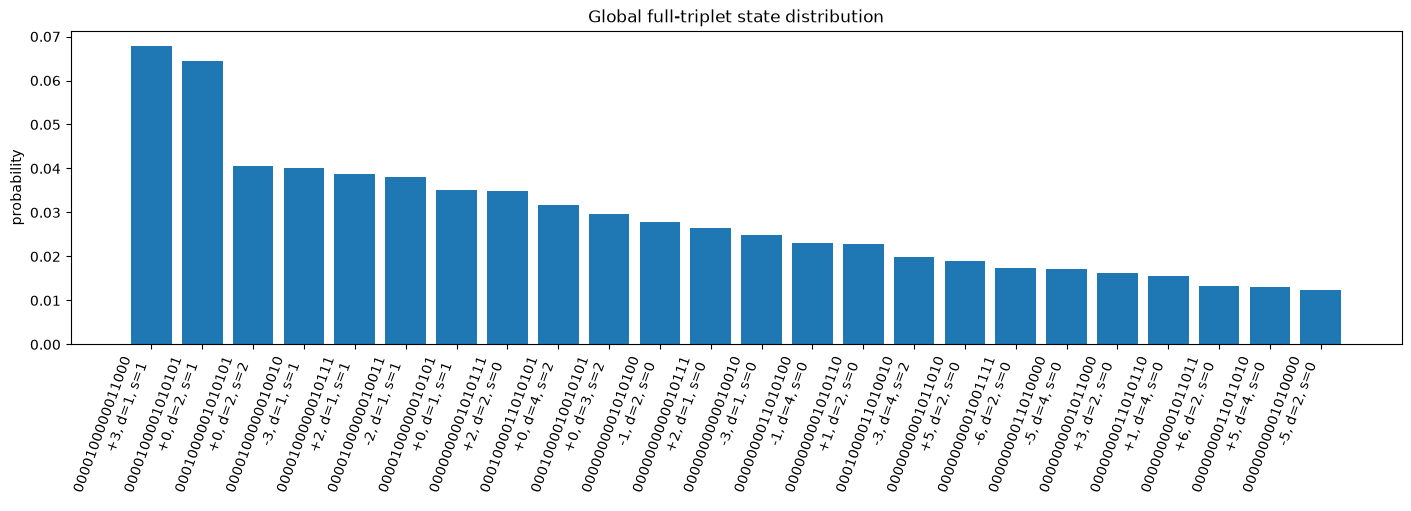

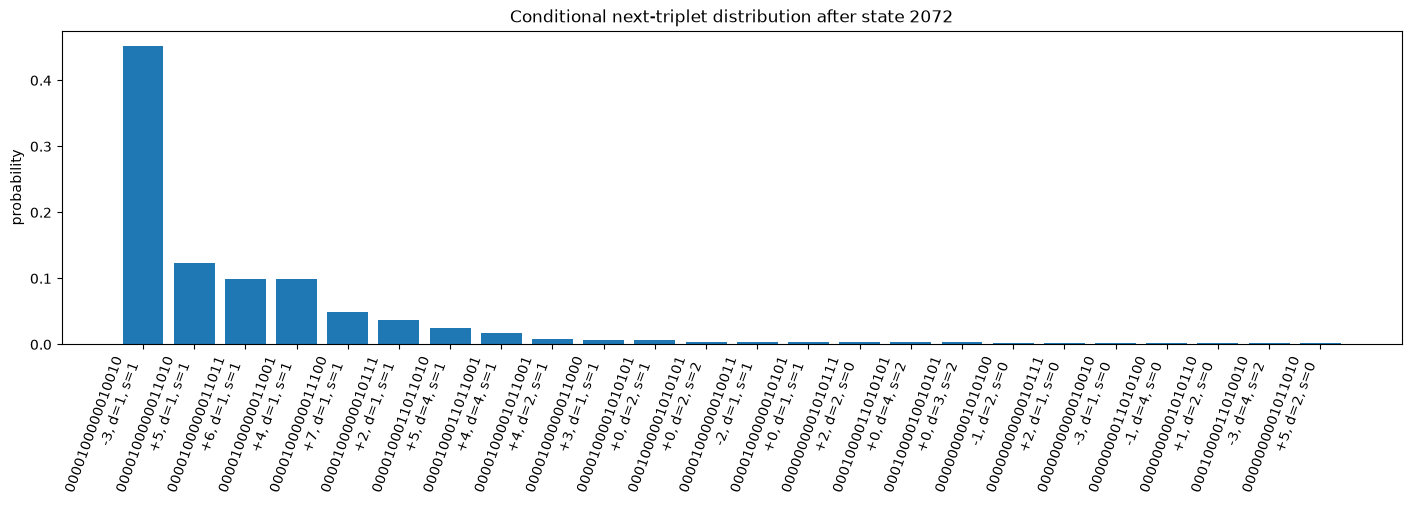

In [30]:
def state_label(index: int) -> str:
    try:
        interval, duration, silence = decode_state_index(int(index), repair_invalid_fields=False)
        return f"{int(index):0{NUM_QUBITS}b}\n{interval:+d}, d={duration}, s={silence}"
    except ValueError:
        return f"{int(index):0{NUM_QUBITS}b}*"


def save_figure(fig, filename: str) -> Path:
    path = OUTPUT_DIR / filename
    fig.savefig(path, dpi=160, bbox_inches="tight")
    print(f"Saved {path}")
    return path


def plot_state_distribution(probs: np.ndarray, title: str, top_n: int = 24):
    top = np.argsort(probs)[::-1][:top_n]
    labels = [state_label(int(state)) for state in top]
    fig, ax = plt.subplots(figsize=(14, 5), layout="constrained")
    ax.bar(range(len(top)), probs[top])
    ax.set_xticks(range(len(top)), labels, rotation=70, ha="right")
    ax.set_ylabel("probability")
    ax.set_title(title)
    return fig, ax


global_fig, _ = plot_state_distribution(global_probs, "Global full-triplet state distribution")
save_figure(global_fig, "triplet_global_distribution.png")

example_current_state = eligible_current_states[0] if eligible_current_states else int(np.argmax(global_probs))
example_fig, _ = plot_state_distribution(
    conditional_probs.get(example_current_state, global_probs),
    f"Conditional next-triplet distribution after state {example_current_state}",
)
save_figure(example_fig, "triplet_example_conditional_distribution.png")


## 6. Build Qiskit circuits and knob blocks

`StatePreparation` loads the learned distribution. The knob block is appended afterward and before measurement. `NONE` leaves that parameter group unchanged. `RY` is applied to every bit in the selected parameter group. `CRY` and `CRX` are applied as a ladder over consecutive bits in that group: `q0 -> q1 -> q2 -> ...`. A controlled gate on a one-bit group has no pair to connect, so it is skipped for that group.


Global parameter-vs-rest entropies before knob layer:
interval: 1.923 bits / max 6.0, Schmidt rank 23
duration: 1.493 bits / max 5.0, Schmidt rank 16
silence : 1.398 bits / max 5.0, Schmidt rank 10
Example conditional parameter-vs-rest entropies before knob layer:
interval: 0.688 bits / max 6.0, Schmidt rank 23
duration: 0.558 bits / max 5.0, Schmidt rank 16
silence : 0.372 bits / max 5.0, Schmidt rank 10


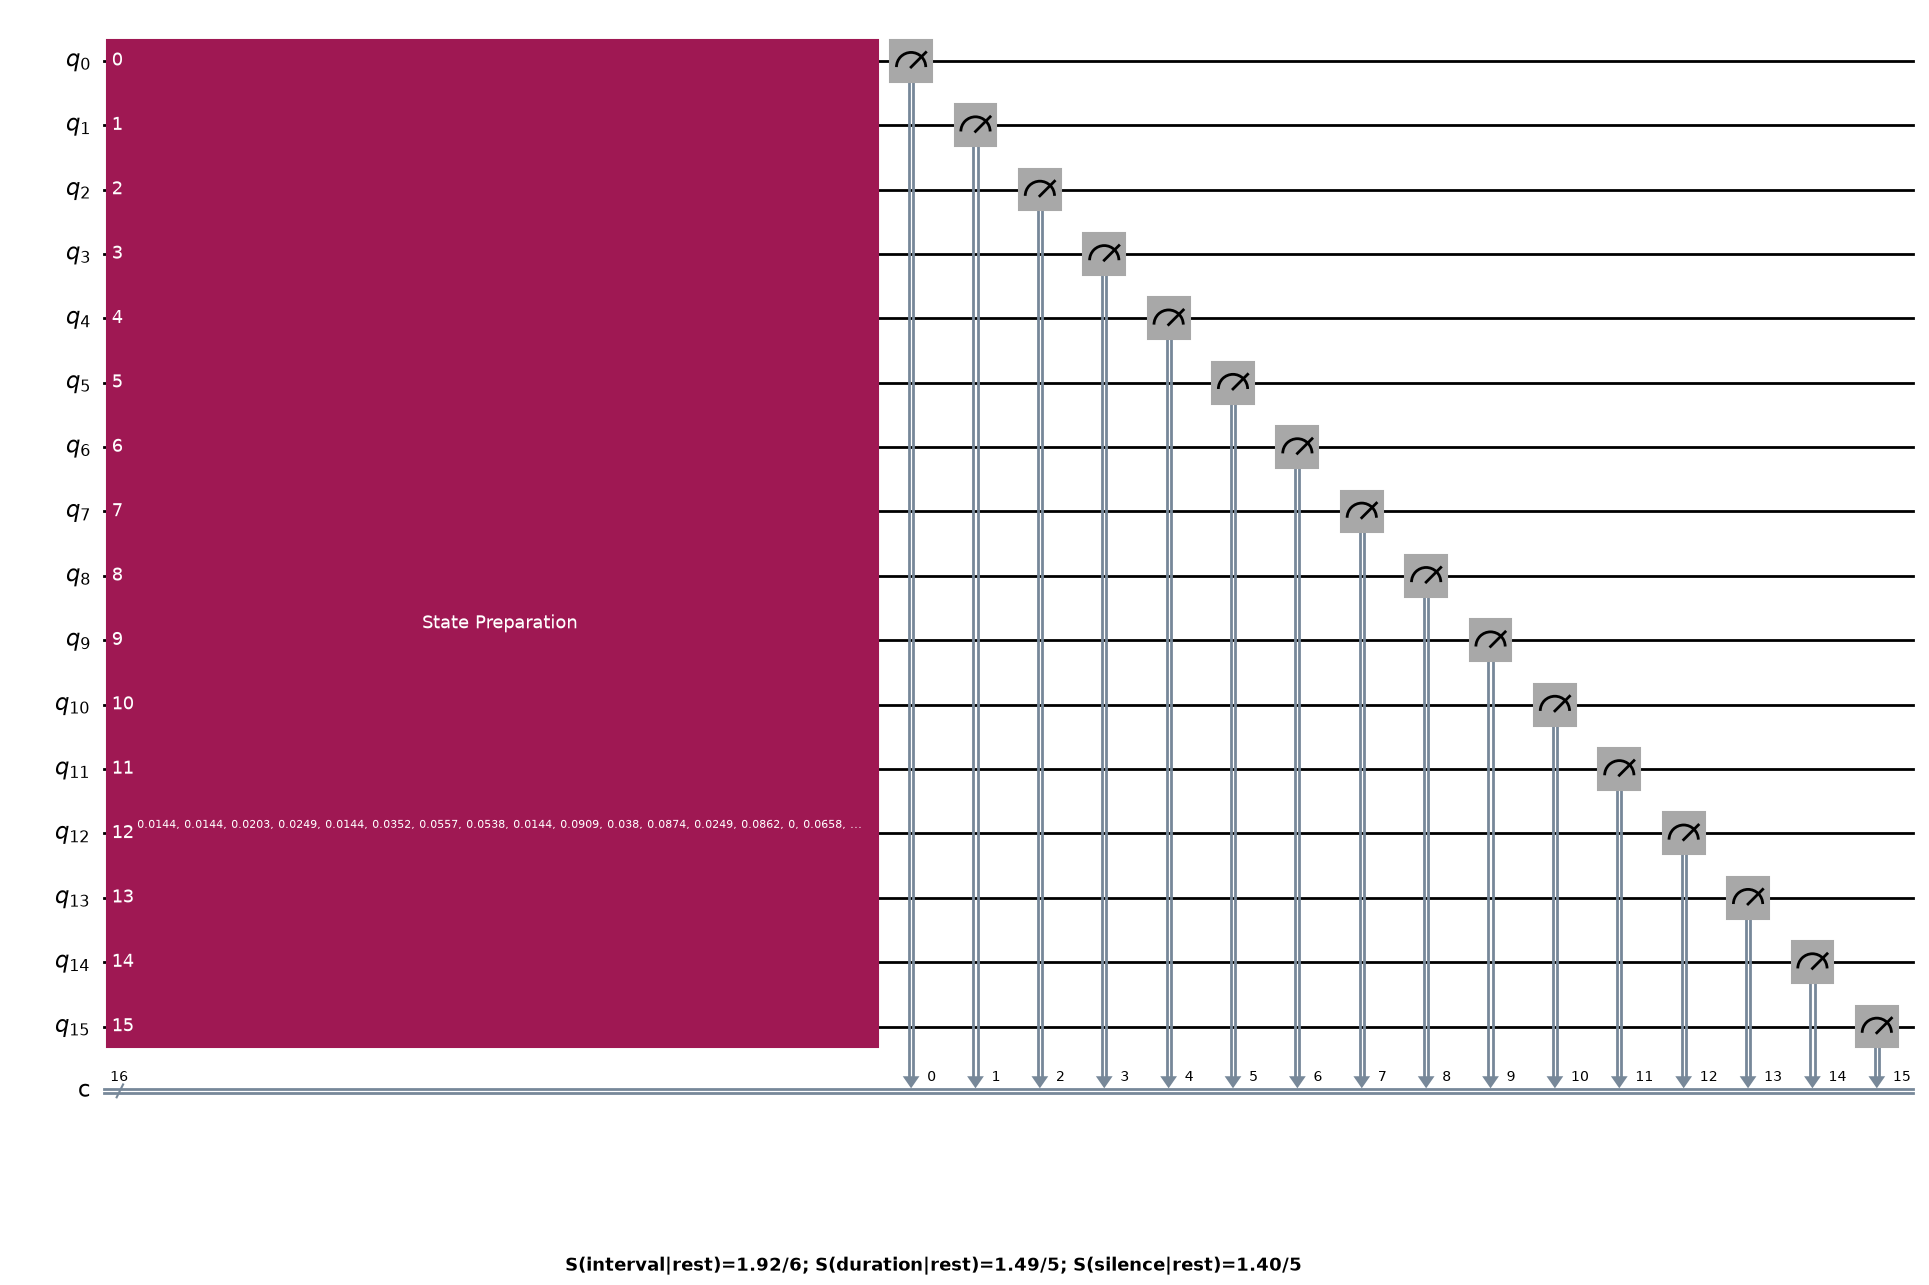

Saved outputs_triplet_knobs/triplet_global_circuit.png
Saved outputs_triplet_knobs/triplet_gate_entropy_summary.txt


In [31]:
from IPython.display import display
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import StatePreparation
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector

VALID_KNOB_GATES = ("NONE", "RY", "CRY", "CRX")
ENTROPY_CAPTION_FONTSIZE = 13
DEFAULT_KNOB_CONFIG = {
    "interval": {"gate": "NONE", "angle": 0.0},
    "duration": {"gate": "NONE", "angle": 0.0},
    "silence": {"gate": "NONE", "angle": 0.0},
}


def probs_to_amplitudes(probs: np.ndarray) -> np.ndarray:
    probs = np.asarray(probs, dtype=float)
    probs = probs / probs.sum()
    amps = np.sqrt(probs)
    assert np.isclose(np.linalg.norm(amps), 1.0)
    return amps


def bipartite_entropy_bits(amplitudes: np.ndarray, left_qubits: list[int], tol: float = 1e-12) -> tuple[float, int, float]:
    tensor = amplitudes.reshape([2] * NUM_QUBITS, order="F")
    right_qubits = [q for q in range(NUM_QUBITS) if q not in set(left_qubits)]
    permuted = np.moveaxis(tensor, left_qubits + right_qubits, list(range(NUM_QUBITS)))
    matrix = permuted.reshape((2 ** len(left_qubits), -1))
    schmidt = np.linalg.svd(matrix, compute_uv=False)
    weights = schmidt ** 2
    weights = weights[weights > tol]
    entropy = -float(np.sum(weights * np.log2(weights))) if len(weights) else 0.0
    return entropy, int(len(weights)), float(min(len(left_qubits), NUM_QUBITS - len(left_qubits)))


def distribution_entropies(amplitudes: np.ndarray) -> dict[str, tuple[float, int, float]]:
    return {
        name: bipartite_entropy_bits(amplitudes, qubits)
        for name, qubits in PARAMETER_QUBITS.items()
        if qubits and len(qubits) < NUM_QUBITS
    }


def normalize_knob_config(knob_config: dict | None) -> dict[str, dict[str, float | str]]:
    config = {}
    source = knob_config or DEFAULT_KNOB_CONFIG
    for name in ("interval", "duration", "silence"):
        entry = source.get(name, DEFAULT_KNOB_CONFIG[name])
        gate = str(entry.get("gate", "RY")).upper()
        if gate not in VALID_KNOB_GATES:
            raise ValueError(f"Unsupported gate for {name}: {gate}")
        config[name] = {"gate": gate, "angle": float(entry.get("angle", 0.0))}
    return config


def knob_signature(knob_config: dict | None) -> tuple[tuple[str, str, float], ...]:
    config = normalize_knob_config(knob_config)
    return tuple((name, str(config[name]["gate"]), round(float(config[name]["angle"]), 12)) for name in ("interval", "duration", "silence"))


def append_knob_block(circuit: QuantumCircuit, knob_config: dict | None) -> QuantumCircuit:
    config = normalize_knob_config(knob_config)
    for name in ("interval", "duration", "silence"):
        qubits = PARAMETER_QUBITS[name]
        gate = str(config[name]["gate"])
        angle = float(config[name]["angle"])
        if gate == "NONE" or abs(angle) < 1e-12 or not qubits:
            continue
        circuit.barrier(qubits, label=f"{name} knob")
        if gate == "RY":
            for qubit in qubits:
                circuit.ry(angle, qubit)
        elif gate == "CRY":
            for control, target in zip(qubits, qubits[1:]):
                circuit.cry(angle, control, target)
        elif gate == "CRX":
            for control, target in zip(qubits, qubits[1:]):
                circuit.crx(angle, control, target)
        else:
            raise ValueError(f"Unsupported knob gate: {gate}")
    return circuit


def build_triplet_sampler(probs: np.ndarray, name: str, knob_config: dict | None = None, measure: bool = True) -> tuple[QuantumCircuit, np.ndarray, dict[str, tuple[float, int, float]]]:
    amplitudes = probs_to_amplitudes(probs)
    circuit = QuantumCircuit(NUM_QUBITS, NUM_QUBITS if measure else 0, name=name)
    circuit.append(StatePreparation(amplitudes), range(NUM_QUBITS))
    append_knob_block(circuit, knob_config)
    if measure:
        circuit.measure(range(NUM_QUBITS), range(NUM_QUBITS))
    return circuit, amplitudes, distribution_entropies(amplitudes)


global_circuit, global_amplitudes, global_entropies = build_triplet_sampler(global_probs, "global_full_triplet_sampler")
example_circuit, _, example_entropies = build_triplet_sampler(
    conditional_probs.get(example_current_state, global_probs),
    f"next_after_{example_current_state}",
)

print("Global parameter-vs-rest entropies before knob layer:")
for name, (entropy, rank, max_entropy) in global_entropies.items():
    print(f"{name:8s}: {entropy:.3f} bits / max {max_entropy:.1f}, Schmidt rank {rank}")
print("Example conditional parameter-vs-rest entropies before knob layer:")
for name, (entropy, rank, max_entropy) in example_entropies.items():
    print(f"{name:8s}: {entropy:.3f} bits / max {max_entropy:.1f}, Schmidt rank {rank}")

if DRAW_CIRCUIT_IMAGES:
    global_fig = global_circuit.draw(output="mpl", fold=80)
    global_fig.text(
        0.5,
        0.01,
        "; ".join(f"S({name}|rest)={entropy:.2f}/{max_entropy:.0f}" for name, (entropy, _, max_entropy) in global_entropies.items()),
        ha="center",
        va="bottom",
        fontsize=ENTROPY_CAPTION_FONTSIZE,
        fontweight="bold",
    )
    global_fig.savefig(OUTPUT_DIR / "triplet_global_circuit.png", dpi=160, bbox_inches="tight")
    display(global_fig)
    print(f"Saved {OUTPUT_DIR / 'triplet_global_circuit.png'}")

summary_lines = [
    "Full-triplet Markov sampler summary",
    f"qubits: {NUM_QUBITS} = {INTERVAL_BITS} interval + {DURATION_BITS} duration + {SILENCE_BITS} silence",
    f"state vector length: {STATE_SIZE}",
    f"conditional circuits/probability rows: {len(conditional_probs)}",
]
for name, (entropy, rank, max_entropy) in global_entropies.items():
    summary_lines.append(f"global S({name}|rest): {entropy:.3f}/{max_entropy:.1f} bits, Schmidt rank {rank}")
summary_path = OUTPUT_DIR / "triplet_gate_entropy_summary.txt"
summary_path.write_text("\n".join(summary_lines) + "\n")
print(f"Saved {summary_path}")


## 7. Generate from the knobbed Markov circuits

At each step, the current measured full-triplet state selects a conditional distribution if one was learned. Otherwise the generator uses the global circuit. The same knob configuration is appended to whichever circuit is selected. For responsiveness, sampling applies the configured `RY`/`CRY`/`CRX` gates directly to the dense amplitude vector instead of repeatedly transpiling `StatePreparation` through Aer.


In [32]:
ideal_simulator = AerSimulator(seed_simulator=SEED)


def choose_markov_source(current_state: int, rng: np.random.Generator) -> tuple[str, bool]:
    has_conditional = current_state in conditional_probs
    use_global_mix = rng.random() < GLOBAL_MIX_PROBABILITY
    if has_conditional and not use_global_mix:
        return "conditional", True
    return ("global_mix" if has_conditional else "global_fallback"), False


def repair_state_index(sampled_state: int, source: str) -> tuple[int, str]:
    interval, duration, silence = decode_state_index(sampled_state, repair_invalid_fields=True)
    repaired = encode_triplet((interval, duration, silence))
    if repaired == sampled_state:
        return repaired, source
    return repaired, source + "+repair"


def make_sampler_from_probs(probs: np.ndarray, name: str, knob_config: dict | None, measure: bool = True) -> QuantumCircuit:
    circuit, _, _ = build_triplet_sampler(probs, name, knob_config=knob_config, measure=measure)
    return circuit


def repair_probability_vector(raw_probs: np.ndarray) -> np.ndarray:
    repaired = np.zeros(STATE_SIZE, dtype=float)
    for state, probability in enumerate(raw_probs):
        if probability <= 0:
            continue
        repaired_state, _ = repair_state_index(state, "probability")
        repaired[repaired_state] += probability
    repaired /= repaired.sum()
    return repaired


def apply_single_qubit_gate(amplitudes: np.ndarray, target: int, matrix: np.ndarray) -> np.ndarray:
    result = amplitudes.copy()
    mask = 1 << target
    for base in range(0, STATE_SIZE, mask << 1):
        for offset in range(mask):
            i0 = base + offset
            i1 = i0 + mask
            a0 = result[i0]
            a1 = result[i1]
            result[i0] = matrix[0, 0] * a0 + matrix[0, 1] * a1
            result[i1] = matrix[1, 0] * a0 + matrix[1, 1] * a1
    return result


def apply_controlled_gate(amplitudes: np.ndarray, control: int, target: int, matrix: np.ndarray) -> np.ndarray:
    result = amplitudes.copy()
    control_mask = 1 << control
    target_mask = 1 << target
    for i0 in range(STATE_SIZE):
        if (i0 & control_mask) and not (i0 & target_mask):
            i1 = i0 | target_mask
            a0 = result[i0]
            a1 = result[i1]
            result[i0] = matrix[0, 0] * a0 + matrix[0, 1] * a1
            result[i1] = matrix[1, 0] * a0 + matrix[1, 1] * a1
    return result


def rotation_matrix(gate: str, angle: float) -> np.ndarray:
    c = np.cos(angle / 2)
    s = np.sin(angle / 2)
    if gate in ("RY", "CRY"):
        return np.array([[c, -s], [s, c]], dtype=complex)
    if gate == "CRX":
        return np.array([[c, -1j * s], [-1j * s, c]], dtype=complex)
    raise ValueError(f"Unsupported rotation gate: {gate}")


def knobbed_amplitudes(probs: np.ndarray, knob_config: dict | None) -> np.ndarray:
    amplitudes = probs_to_amplitudes(probs).astype(complex)
    config = normalize_knob_config(knob_config)
    for name in ("interval", "duration", "silence"):
        qubits = PARAMETER_QUBITS[name]
        gate = str(config[name]["gate"])
        angle = float(config[name]["angle"])
        if gate == "NONE" or abs(angle) < 1e-12 or not qubits:
            continue
        matrix = rotation_matrix(gate, angle)
        if gate == "RY":
            for qubit in qubits:
                amplitudes = apply_single_qubit_gate(amplitudes, qubit, matrix)
        elif gate in ("CRY", "CRX"):
            for control, target in zip(qubits, qubits[1:]):
                amplitudes = apply_controlled_gate(amplitudes, control, target, matrix)
    return amplitudes


def knobbed_probability_vector(probs: np.ndarray, knob_config: dict | None) -> np.ndarray:
    amplitudes = knobbed_amplitudes(probs, knob_config)
    raw_probs = np.abs(amplitudes) ** 2
    raw_probs /= raw_probs.sum()
    return repair_probability_vector(raw_probs)


def sample_quantum_next_state(
    current_state: int,
    step: int,
    knob_config: dict | None,
    circuit_cache: dict,
    rng: np.random.Generator,
) -> tuple[int, str]:
    source, use_conditional = choose_markov_source(current_state, rng)
    probs = conditional_probs[current_state] if use_conditional else global_probs
    key_state = current_state if use_conditional else "global"
    key = (key_state, knob_signature(knob_config))
    if key not in circuit_cache:
        circuit_cache[key] = knobbed_probability_vector(probs, knob_config)

    sampled_state = int(rng.choice(np.arange(STATE_SIZE), p=circuit_cache[key]))
    return sampled_state, source


def generate_triplet_states(
    n_events: int = GENERATED_EVENTS,
    knob_config: dict | None = None,
    start_state: int | None = None,
    seed_offset: int = 700,
) -> tuple[list[int], Counter]:
    states = []
    source_counts = Counter()
    current = encoded_sequences[0][0] if start_state is None else start_state
    local_rng = np.random.default_rng(SEED + seed_offset)
    circuit_cache = {}

    for step in range(n_events):
        next_state, source = sample_quantum_next_state(current, step, knob_config, circuit_cache, local_rng)
        states.append(next_state)
        source_counts[source] += 1
        current = next_state

    return states, source_counts


print(f"Default start state: {encoded_sequences[0][0]} -> {decode_state_index(encoded_sequences[0][0])}")
print("Generation functions are ready. Use the UI below, or call generate_triplet_states(...).")


Default start state: 2133 -> (0, 2, 1)
Generation functions are ready. Use the UI below, or call generate_triplet_states(...).


## 8. Reconstruct and export audio

Each measured state decodes to `(interval, duration, silence)`. The silence is inserted before the note in both the MIDI and square-wave WAV output.


In [33]:
def reflect_pitch_into_range(pitch: int, low: int = OUTPUT_LOW_PITCH, high: int = OUTPUT_HIGH_PITCH) -> int:
    while pitch < low or pitch > high:
        if pitch < low:
            pitch = low + (low - pitch)
        if pitch > high:
            pitch = high - (pitch - high)
    return int(pitch)


def states_to_melody(states: list[int], start_pitch: int) -> tuple[list[int], list[int], list[int]]:
    pitch = start_pitch
    pitches = []
    durations = []
    silences = []
    for state in states:
        interval, duration_steps, silence_steps = decode_state_index(state, repair_invalid_fields=True)
        pitch = reflect_pitch_into_range(pitch + interval)
        pitches.append(pitch)
        durations.append(duration_steps_to_ticks(duration_steps))
        silences.append(silence_steps_to_ticks(silence_steps))
    return pitches, durations, silences


def write_vlq(value: int) -> bytes:
    buffer = [value & 0x7F]
    value >>= 7
    while value:
        buffer.append((value & 0x7F) | 0x80)
        value >>= 7
    return bytes(reversed(buffer))


def write_generated_midi(path: Path, pitches: list[int], durations: list[int], silences: list[int], velocity: int = 96, program: int = 80):
    track = bytearray()
    track += write_vlq(0) + bytes([0xFF, 0x51, 0x03]) + OUTPUT_TEMPO_US_PER_BEAT.to_bytes(3, "big")
    track += write_vlq(0) + bytes([0xC0, program])
    for pitch, duration, silence in zip(pitches, durations, silences):
        pitch = int(np.clip(pitch, 0, 127))
        track += write_vlq(max(0, int(silence))) + bytes([0x90, pitch, velocity])
        track += write_vlq(max(1, int(duration))) + bytes([0x80, pitch, 0])
    track += write_vlq(0) + bytes([0xFF, 0x2F, 0x00])

    header = b"MThd" + (6).to_bytes(4, "big") + (0).to_bytes(2, "big") + (1).to_bytes(2, "big") + OUTPUT_TICKS_PER_BEAT.to_bytes(2, "big")
    chunk = b"MTrk" + len(track).to_bytes(4, "big") + bytes(track)
    path.write_bytes(header + chunk)


def midi_pitch_to_frequency(pitch: int) -> float:
    return 440.0 * (2.0 ** ((pitch - 69) / 12.0))


def synth_square_wave(pitches: list[int], durations: list[int], silences: list[int], sample_rate: int = 22_050, amplitude: float = 0.25) -> np.ndarray:
    chunks = []
    seconds_per_tick = OUTPUT_TEMPO_US_PER_BEAT / 1_000_000 / OUTPUT_TICKS_PER_BEAT
    for pitch, duration_ticks, silence_ticks in zip(pitches, durations, silences):
        silence_samples = int(round(max(0, silence_ticks) * seconds_per_tick * sample_rate))
        if silence_samples:
            chunks.append(np.zeros(silence_samples))

        duration_seconds = max(0.02, duration_ticks * seconds_per_tick)
        n = max(1, int(round(duration_seconds * sample_rate)))
        t = np.arange(n) / sample_rate
        wave_chunk = amplitude * np.sign(np.sin(2 * np.pi * midi_pitch_to_frequency(pitch) * t))
        fade = min(n // 2, int(0.005 * sample_rate))
        if fade > 1:
            envelope = np.ones(n)
            envelope[:fade] = np.linspace(0, 1, fade)
            envelope[-fade:] = np.linspace(1, 0, fade)
            wave_chunk *= envelope
        chunks.append(wave_chunk)
    return np.concatenate(chunks) if chunks else np.array([], dtype=float)


def write_wav(path: Path, audio: np.ndarray, sample_rate: int = 22_050):
    audio_i16 = np.int16(np.clip(audio, -1, 1) * 32767)
    with wave.open(str(path), "wb") as f:
        f.setnchannels(1)
        f.setsampwidth(2)
        f.setframerate(sample_rate)
        f.writeframes(audio_i16.tobytes())


def export_generation(name: str, states: list[int]) -> tuple[Path, Path, np.ndarray]:
    pitches, durations, silences = states_to_melody(states, START_PITCH)
    midi_path = OUTPUT_DIR / f"generated_{name}.mid"
    wav_path = OUTPUT_DIR / f"generated_{name}.wav"
    write_generated_midi(midi_path, pitches, durations, silences)
    audio = synth_square_wave(pitches, durations, silences)
    write_wav(wav_path, audio)
    print(f"{name}: wrote {midi_path}")
    print(f"{name}: wrote {wav_path}")
    print(f"First 16 {name} pitch/duration/silence ticks:")
    print(list(zip(pitches, durations, silences))[:16])
    return midi_path, wav_path, audio


## 9. Preview how knob gates change the global distribution

This cell keeps the original sampled side-by-side plot of the unmodified global circuit and the knobbed global circuit. It also annotates that plot with exact divergence values computed from the pre-sampling probability vectors, so the comparison remains readable even when one distribution visually dominates. The cell also saves an image of the global circuit with the configured knob block appended.


In [34]:
def sample_probability_vector(probs: np.ndarray, shots: int, seed: int) -> np.ndarray:
    local_rng = np.random.default_rng(seed)
    samples = local_rng.choice(np.arange(STATE_SIZE), size=shots, p=probs)
    counts = np.bincount(samples, minlength=STATE_SIZE).astype(float)
    return counts / counts.sum()


def entropy_caption(entropies: dict[str, tuple[float, int, float]]) -> str:
    return "; ".join(
        f"S({name}|rest)={entropy:.2f}/{max_entropy:.0f}"
        for name, (entropy, _, max_entropy) in entropies.items()
    )


def kl_divergence_bits(p: np.ndarray, q: np.ndarray, eps: float = 1e-12) -> float:
    p = np.clip(np.asarray(p, dtype=float), eps, 1.0)
    q = np.clip(np.asarray(q, dtype=float), eps, 1.0)
    p = p / p.sum()
    q = q / q.sum()
    return float(np.sum(p * np.log2(p / q)))


def distribution_divergences(reference: np.ndarray, candidate: np.ndarray) -> dict[str, float]:
    reference = np.asarray(reference, dtype=float)
    candidate = np.asarray(candidate, dtype=float)
    reference = reference / reference.sum()
    candidate = candidate / candidate.sum()
    midpoint = 0.5 * (reference + candidate)
    return {
        "tvd": float(0.5 * np.abs(candidate - reference).sum()),
        "js_bits": 0.5 * kl_divergence_bits(reference, midpoint) + 0.5 * kl_divergence_bits(candidate, midpoint),
        "kl_knobbed_vs_base_bits": kl_divergence_bits(candidate, reference),
    }


def save_knobbed_global_circuit_image(
    knob_config: dict | None,
    filename: str = "triplet_global_knobbed_circuit.png",
) -> tuple[Path, dict[str, tuple[float, int, float]]]:
    modified_circuit = make_sampler_from_probs(global_probs, "global_with_user_knobs", knob_config)
    fig = modified_circuit.draw(output="mpl", fold=80)
    config = normalize_knob_config(knob_config)
    caption = "; ".join(
        f"{name}: {entry['gate']}({entry['angle']:.3f})" if entry["gate"] != "NONE" else f"{name}: NONE"
        for name, entry in config.items()
    )
    knobbed_entropies = distribution_entropies(knobbed_amplitudes(global_probs, config))
    fig.text(
        0.5,
        0.01,
        f"Appended knob block: {caption}\nKnobbed global entropy: {entropy_caption(knobbed_entropies)}",
        ha="center",
        va="bottom",
        fontsize=ENTROPY_CAPTION_FONTSIZE,
        fontweight="bold",
    )
    path = OUTPUT_DIR / filename
    fig.savefig(path, dpi=160, bbox_inches="tight")
    print(f"Saved {path}")
    print("Knobbed global parameter-vs-rest entropies:")
    for name, (entropy, rank, max_entropy) in knobbed_entropies.items():
        print(f"{name:8s}: {entropy:.3f} bits / max {max_entropy:.1f}, Schmidt rank {rank}")
    try:
        display(fig)
    except Exception:
        pass
    return path, knobbed_entropies


def run_global_distribution_preview(
    knob_config: dict | None,
    shots: int = DISTRIBUTION_PREVIEW_SHOTS,
    filename: str = "triplet_global_knob_preview.png",
    circuit_filename: str = "triplet_global_knobbed_circuit.png",
) -> tuple[np.ndarray, np.ndarray, Path, Path, dict[str, float]]:
    unmodified_exact = knobbed_probability_vector(global_probs, DEFAULT_KNOB_CONFIG)
    modified_exact = knobbed_probability_vector(global_probs, knob_config)
    circuit_path, knobbed_entropies = save_knobbed_global_circuit_image(knob_config, circuit_filename)

    exact_divergences = distribution_divergences(unmodified_exact, modified_exact)
    unmodified_probs = sample_probability_vector(unmodified_exact, shots=shots, seed=SEED + 31)
    modified_probs = sample_probability_vector(modified_exact, shots=shots, seed=SEED + 32)
    delta = modified_probs - unmodified_probs

    interesting = np.argsort(np.maximum(unmodified_probs, modified_probs))[::-1][:18]
    labels = [state_label(int(state)) for state in interesting]
    x = np.arange(len(interesting))
    width = 0.42
    fig, ax = plt.subplots(figsize=(14, 5), layout="constrained")
    ax.bar(x - width / 2, unmodified_probs[interesting], width, label="unmodified global")
    ax.bar(x + width / 2, modified_probs[interesting], width, label="knobbed global")
    ax.set_xticks(x, labels, rotation=70, ha="right")
    ax.set_ylabel("sampled probability")
    ax.set_title(f"Global circuit distribution preview, shots={shots}")
    annotation = (
        "Exact divergence\n"
        f"TVD = {exact_divergences['tvd']:.3f}\n"
        f"JS = {exact_divergences['js_bits']:.3f} bits\n"
        f"KL(knobbed || base) = {exact_divergences['kl_knobbed_vs_base_bits']:.3f} bits"
    )
    ax.text(
        0.985,
        0.95,
        annotation,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=11,
        bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "0.35", "alpha": 0.9},
    )
    ax.legend(loc="upper left")
    path = save_figure(fig, filename)

    sampled_tvd = 0.5 * np.abs(delta).sum()
    print(
        "Exact global divergence knobbed vs unmodified: "
        f"TVD={exact_divergences['tvd']:.3f}, "
        f"JS={exact_divergences['js_bits']:.3f} bits, "
        f"KL(knobbed || base)={exact_divergences['kl_knobbed_vs_base_bits']:.3f} bits"
    )
    print(f"Sampled global preview TVD(knobbed, unmodified) from {shots} shots: {sampled_tvd:.3f}")
    print("Largest probability shifts:")
    for state in np.argsort(np.abs(delta))[::-1][:8]:
        if abs(delta[state]) <= 0:
            continue
        print(f"state={int(state):5d} delta={delta[state]:+.4f} -> {decode_state_index(int(state))}")
    return unmodified_probs, modified_probs, path, circuit_path, exact_divergences


## 10. Interactive knob UI

Set a gate and angle for each parameter group. Choose `NONE` to leave a group unchanged. Press **Generate** to create a new MIDI/WAV preview and then sample the modified global circuit for comparison. Press **Preview global distribution** to inspect the distribution effect without generating a melody.


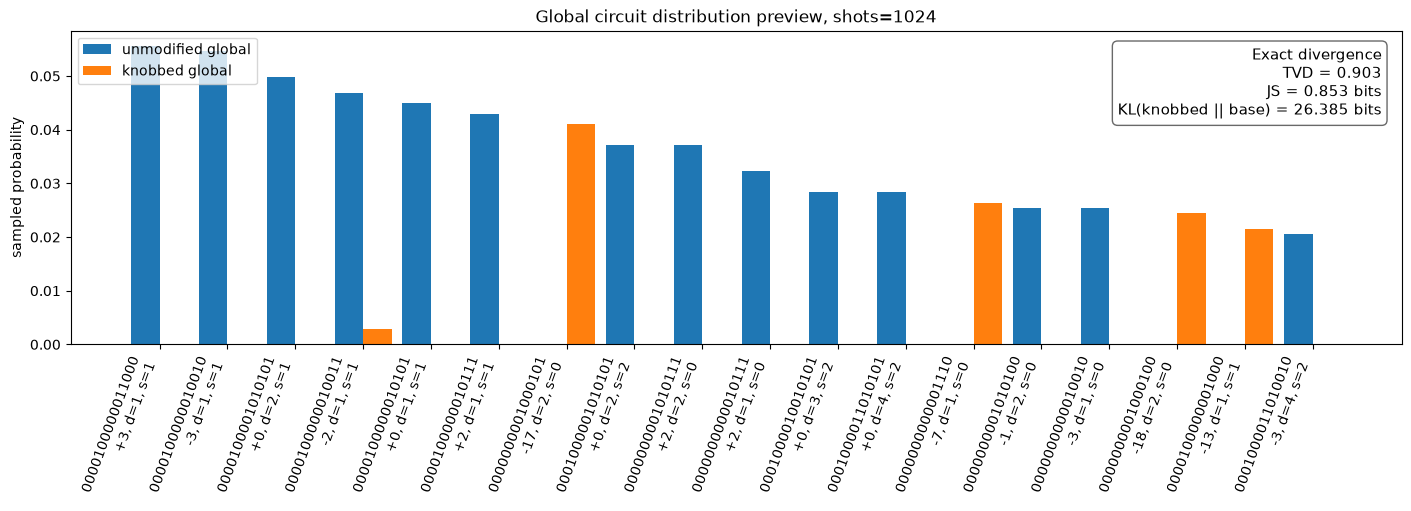

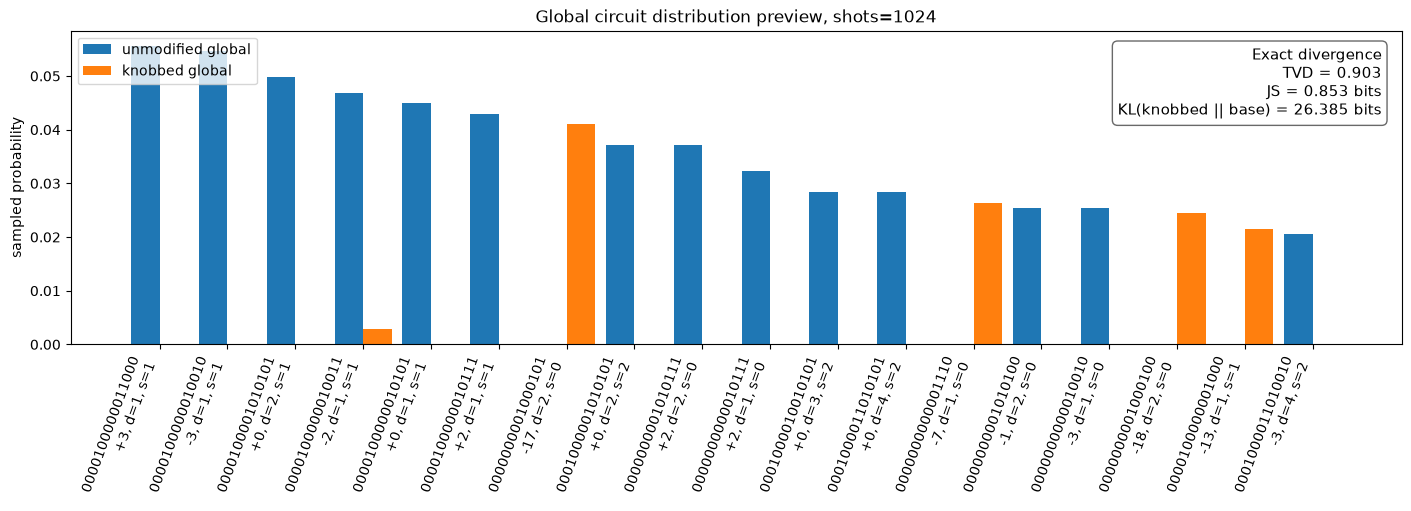

In [ ]:
def collect_knob_config(gate_widgets: dict, angle_widgets: dict) -> dict[str, dict[str, float | str]]:
    return {
        name: {"gate": gate_widgets[name].value, "angle": float(angle_widgets[name].value)}
        for name in ("interval", "duration", "silence")
    }


def run_knobbed_generation(
    knob_config: dict | None,
    n_events: int = GENERATED_EVENTS,
    preview_shots: int = DISTRIBUTION_PREVIEW_SHOTS,
    output_name: str = "knobbed_full_triplet_markov",
    display_audio: bool = True,
):
    config = normalize_knob_config(knob_config)
    print("Knob config:", config)
    states, sources = generate_triplet_states(n_events=n_events, knob_config=config)
    print("Circuit/distribution sources:", dict(sources))
    print("First 16 generated states/triplets:")
    for state in states[:16]:
        print(f"state={state:5d} bits={state:0{NUM_QUBITS}b} -> {decode_state_index(state)}")

    midi_path, wav_path, audio = export_generation(output_name, states)
    run_global_distribution_preview(config, shots=preview_shots)

    if display_audio:
        try:
            from IPython.display import Audio, display
            display(Audio(audio, rate=22_050))
        except Exception as exc:
            print("Inline audio display is unavailable in this environment.")
            print(type(exc).__name__, exc)
    return states, midi_path, wav_path, audio


def create_knob_ui():
    try:
        import ipywidgets as widgets
        from IPython.display import display, clear_output
    except Exception as exc:
        print("ipywidgets is unavailable. Install it with `%pip install ipywidgets` and rerun this cell.")
        print(type(exc).__name__, exc)
        return None

    gate_widgets = {
        name: widgets.Dropdown(options=VALID_KNOB_GATES, value="NONE", description=f"{name} gate")
        for name in ("interval", "duration", "silence")
    }
    angle_widgets = {
        name: widgets.FloatSlider(value=0.0, min=-np.pi, max=np.pi, step=0.025, readout_format=".3f", description=f"{name} angle")
        for name in ("interval", "duration", "silence")
    }
    events_widget = widgets.IntSlider(value=GENERATED_EVENTS, min=16, max=512, step=16, description="events")
    shots_widget = widgets.IntSlider(value=DISTRIBUTION_PREVIEW_SHOTS, min=128, max=8192, step=128, description="shots")
    generate_button = widgets.Button(description="Generate", button_style="primary")
    preview_button = widgets.Button(description="Preview global distribution")
    output = widgets.Output()

    rows = []
    for name in ("interval", "duration", "silence"):
        rows.append(widgets.HBox([gate_widgets[name], angle_widgets[name]]))
    controls = widgets.VBox(rows + [widgets.HBox([events_widget, shots_widget]), widgets.HBox([generate_button, preview_button]), output])

    def on_generate(_):
        with output:
            clear_output(wait=True)
            config = collect_knob_config(gate_widgets, angle_widgets)
            run_knobbed_generation(config, n_events=events_widget.value, preview_shots=shots_widget.value)

    def on_preview(_):
        with output:
            clear_output(wait=True)
            config = collect_knob_config(gate_widgets, angle_widgets)
            print("Knob config:", normalize_knob_config(config))
            run_global_distribution_preview(config, shots=shots_widget.value)

    generate_button.on_click(on_generate)
    preview_button.on_click(on_preview)
    display(controls)
    return controls


knob_ui = create_knob_ui()


## 11. Headless smoke test

This small non-interactive run verifies that the packed full-triplet circuit, knob block, audio export, and global-distribution preview work even outside a live notebook UI.


Knob config: {'interval': {'gate': 'RY', 'angle': 0.12}, 'duration': {'gate': 'CRY', 'angle': 0.08}, 'silence': {'gate': 'CRX', 'angle': -0.06}}
Circuit/distribution sources: {'conditional': 11, 'global_fallback': 4, 'global_mix': 1}
First 16 generated states/triplets:
state=   95 bits=0000000001011111 -> (10, 2, 0)
state=   87 bits=0000000001010111 -> (2, 2, 0)
state=   19 bits=0000000000010011 -> (-2, 1, 0)
state= 2069 bits=0000100000010101 -> (0, 1, 1)
state= 2069 bits=0000100000010101 -> (0, 1, 1)
state= 2133 bits=0000100001010101 -> (0, 2, 1)
state=   95 bits=0000000001011111 -> (10, 2, 0)
state= 4309 bits=0001000011010101 -> (0, 4, 2)
state= 4181 bits=0001000001010101 -> (0, 2, 2)
state= 4182 bits=0001000001010110 -> (1, 2, 2)
state=   87 bits=0000000001010111 -> (2, 2, 0)
state=   86 bits=0000000001010110 -> (1, 2, 0)
state=   45 bits=0000000000101101 -> (36, 1, 0)
state= 2069 bits=0000100000010101 -> (0, 1, 1)
state=   17 bits=0000000000010001 -> (-4, 1, 0)
state=   43 bits=000

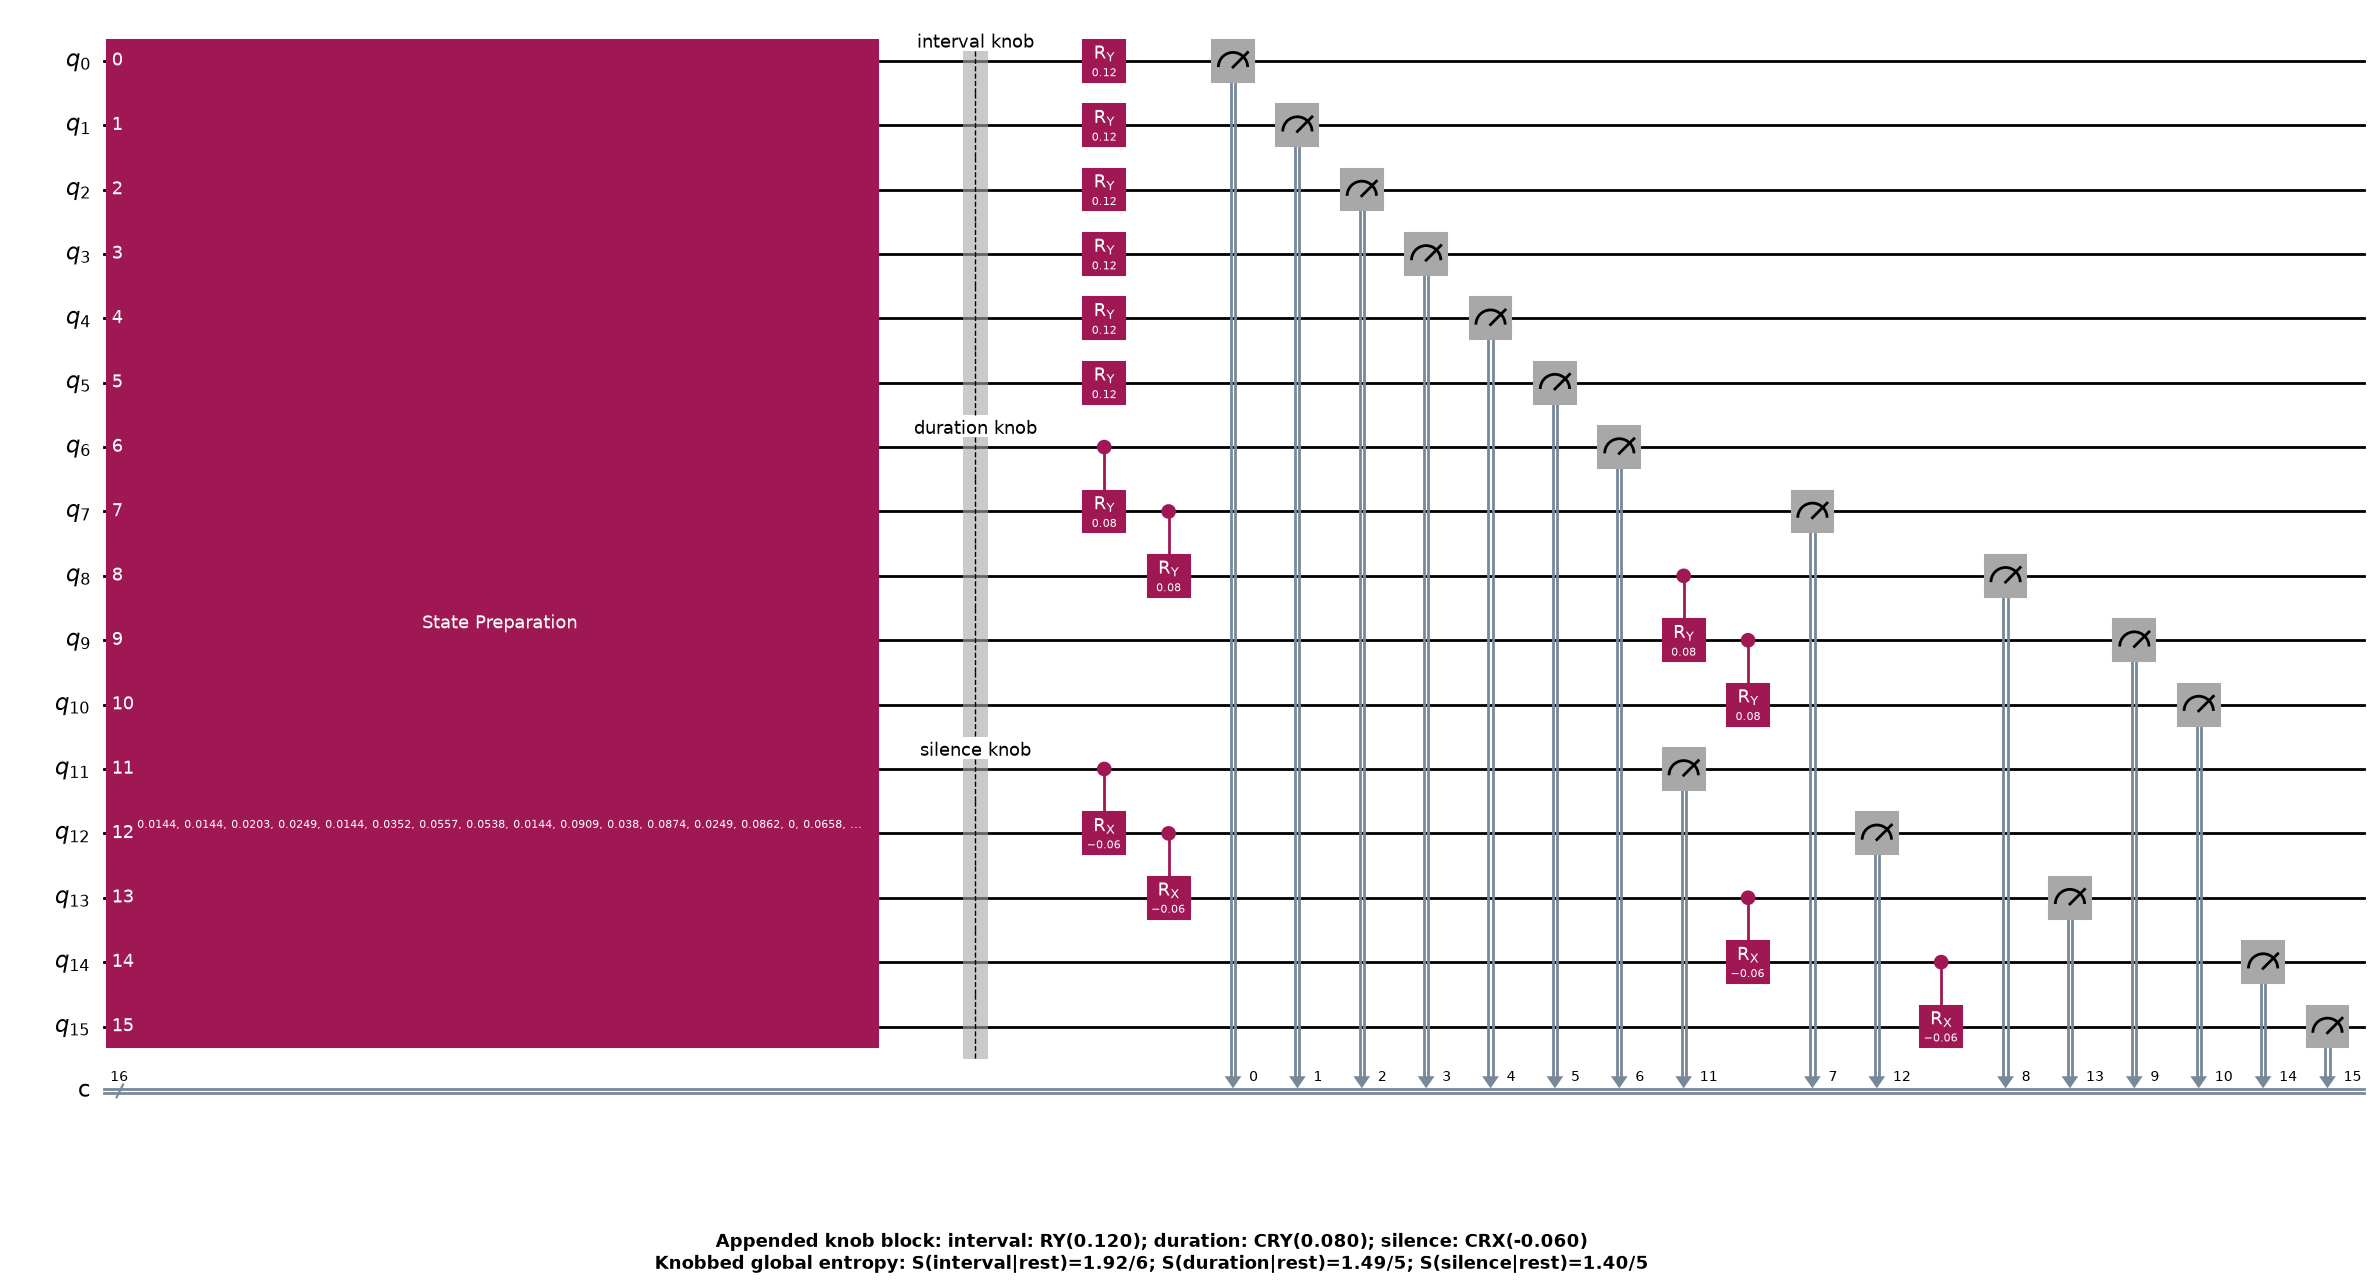

Saved outputs_triplet_knobs/triplet_global_knob_preview.png
Exact global divergence knobbed vs unmodified: TVD=0.085, JS=0.018 bits, KL(knobbed || base)=0.492 bits
Sampled global preview TVD(knobbed, unmodified) from 256 shots: 0.320
Largest probability shifts:
state=   18 delta=-0.0312 -> (-3, 1, 0)
state= 2067 delta=-0.0273 -> (-2, 1, 1)
state=   79 delta=+0.0273 -> (-6, 2, 0)
state=   23 delta=-0.0273 -> (2, 1, 0)
state= 2069 delta=-0.0234 -> (0, 1, 1)
state=   90 delta=+0.0234 -> (5, 2, 0)
state= 2072 delta=+0.0195 -> (3, 1, 1)
state= 4245 delta=+0.0195 -> (0, 3, 2)
Smoke test wrote outputs_triplet_knobs/generated_smoke_knobbed_full_triplet_markov.mid and outputs_triplet_knobs/generated_smoke_knobbed_full_triplet_markov.wav


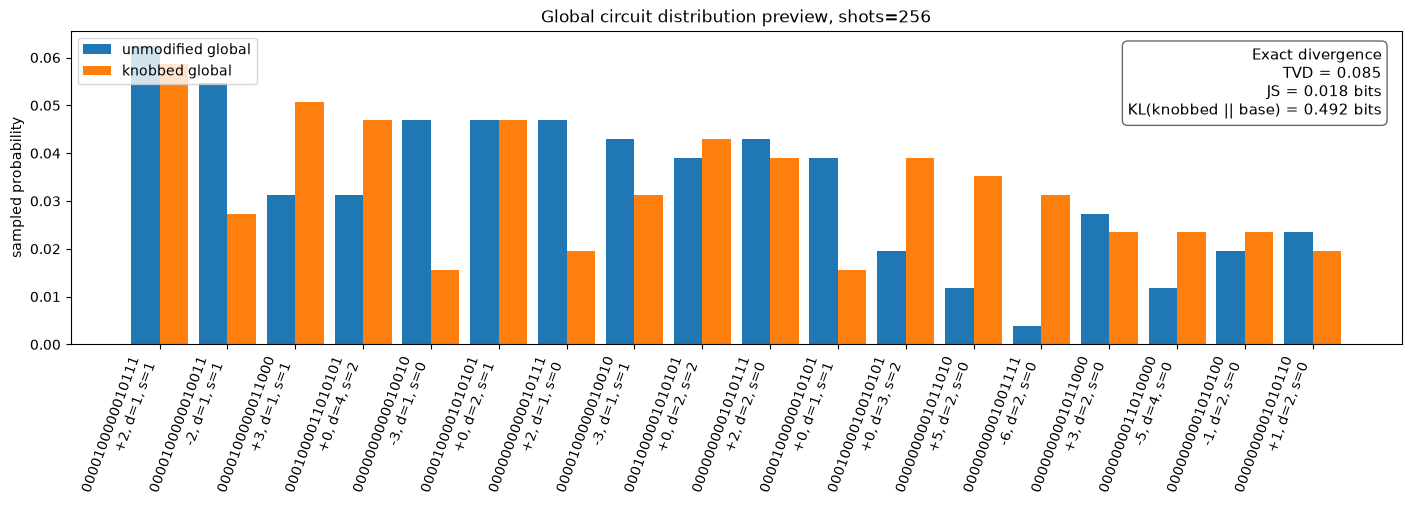

In [36]:
SMOKE_KNOB_CONFIG = {
    "interval": {"gate": "RY", "angle": 0.12},
    "duration": {"gate": "CRY", "angle": 0.08},
    "silence": {"gate": "CRX", "angle": -0.06},
}

if RUN_HEADLESS_SMOKE_TEST:
    smoke_states, smoke_midi_path, smoke_wav_path, smoke_audio = run_knobbed_generation(
        SMOKE_KNOB_CONFIG,
        n_events=SMOKE_TEST_EVENTS,
        preview_shots=SMOKE_PREVIEW_SHOTS,
        output_name="smoke_knobbed_full_triplet_markov",
        display_audio=False,
    )
    print(f"Smoke test wrote {smoke_midi_path} and {smoke_wav_path}")
else:
    print("Headless smoke test is disabled.")


## What to refine next

- Increase `INTERVAL_BITS`, `DURATION_BITS`, and `SILENCE_BITS` if you want to preserve more rare full-triplet field values.
- Try `CRY` first for musically audible distribution changes; `CRX` can also change measurement probabilities, while phase-only rotations would need another non-diagonal layer to matter at measurement.
- Add a temperature control before `StatePreparation` if the Markov rows feel too sharp or too diffuse.
- Cache knobbed conditional circuits more aggressively if you raise event count or qubit count.
